# Home Credit Default Risk — Modelling

This notebook covers the full modelling pipeline for the Home Credit Default Risk
competition, starting from the feature-engineered tables produced in
`02_feature_engineering.ipynb`.

**Pipeline:**
1. Data loading and memory optimisation
2. Baseline LightGBM with 5-fold stratified cross-validation
3. Feature selection (zero-importance removal)
4. Hyperparameter tuning via Optuna (Bayesian optimisation)
5. SHAP model interpretation (global + local)
6. Stacked ensemble — LightGBM + XGBoost + CatBoost
7. Submission file generation

**Final result:** Stacking OOF AUC **0.79165**

**Prerequisites:**
- `data/credit_risk.duckdb` — generated by `02_feature_engineering.ipynb`
- All dependencies installed via `pip install -r requirements.txt`

## 1. Setup & Data Preparation

In [12]:
# ── Dependencies ──────────────────────────────────────────────────────
# pip install lightgbm xgboost catboost optuna shap duckdb scikit-learn
# 
# Or install all at once:
# pip install -r requirements.txt

In [13]:
import duckdb
import pandas as pd
import numpy as np
import lightgbm as lgb
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick

from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import roc_auc_score
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.dpi']        = 130
plt.rcParams['axes.spines.top']   = False
plt.rcParams['axes.spines.right'] = False


con = duckdb.connect(database='data/credit_risk.duckdb', read_only=True)
print("Connected.")

Connected.


In [14]:
# Load train and test into pandas for sklearn/LightGBM
df_train = con.execute("SELECT * FROM app_train_final_v3").fetchdf()
df_test  = con.execute("SELECT * FROM app_test_final").fetchdf()

print(f"Train : {df_train.shape}")
print(f"Test  : {df_test.shape}")

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

MemoryError: cannot allocate memory for array

In [ ]:
def reduce_memory(df: pd.DataFrame, verbose: bool = True) -> pd.DataFrame:
    start_mem = df.memory_usage(deep=True).sum() / 1e6

    for col in df.columns:
        # Convert pandas nullable types to numpy types first
        # (Int32Dtype, Int64Dtype etc. are not handled by np.issubdtype)
        if hasattr(df[col], 'dtype') and isinstance(
            df[col].dtype, pd.api.types.pandas_dtype('Int32').type.__class__
        ):
            df[col] = df[col].astype('float64')

        col_type = df[col].dtype

        if col_type == object:
            continue

        # Safer check — convert to numpy dtype first
        try:
            numpy_type = np.dtype(col_type)
        except TypeError:
            continue

        if np.issubdtype(numpy_type, np.integer):
            c_min = df[col].min()
            c_max = df[col].max()
            if c_min >= np.iinfo(np.int8).min and c_max <= np.iinfo(np.int8).max:
                df[col] = df[col].astype(np.int8)
            elif c_min >= np.iinfo(np.int16).min and c_max <= np.iinfo(np.int16).max:
                df[col] = df[col].astype(np.int16)
            elif c_min >= np.iinfo(np.int32).min and c_max <= np.iinfo(np.int32).max:
                df[col] = df[col].astype(np.int32)

        elif np.issubdtype(numpy_type, np.floating):
            df[col] = df[col].astype(np.float32)

    end_mem = df.memory_usage(deep=True).sum() / 1e6

    if verbose:
        print(f"Memory reduced from {start_mem:.1f} MB "
              f"to {end_mem:.1f} MB "
              f"({(start_mem - end_mem) / start_mem * 100:.1f}% reduction)")

    return df

In [ ]:
# Apply immediately after loading — before any other operation
df_train = reduce_memory(df_train)
df_test  = reduce_memory(df_test)

Memory reduced from 659.3 MB to 365.0 MB (44.6% reduction)
Memory reduced from 104.4 MB to 57.9 MB (44.5% reduction)


In [ ]:
# Check which object columns exist in df_train
object_cols = [c for c in df_train.columns if df_train[c].dtype == object]
print(f"Object columns in df_train ({len(object_cols)}):")
for c in object_cols:
    print(f"  {c:<40} nunique: {df_train[c].nunique()}")

Object columns in df_train (3):
  OCCUPATION_TYPE                          nunique: 18
  ORGANIZATION_TYPE                        nunique: 58
  PREV_LAST_STATUS                         nunique: 3


In [ ]:
# ── Define column groups ──────────────────────────────────────────────
TARGET_COL    = 'TARGET'
ID_COL        = 'SK_ID_CURR'

# High-cardinality string columns — target encoded inside k-fold
TE_COLS       = ['OCCUPATION_TYPE', 'ORGANIZATION_TYPE']

# Columns to exclude from features entirely
EXCLUDE_COLS  = [TARGET_COL, ID_COL, 'PREV_LAST_STATUS'] + TE_COLS

# Final numeric feature list
FEATURE_COLS  = [
    c for c in df_train.columns
    if c not in EXCLUDE_COLS
    and df_train[c].dtype != object
]

print(f"Feature columns   : {len(FEATURE_COLS)}")
print(f"Target encode cols: {TE_COLS}")
print(f"Target distribution:\n{df_train[TARGET_COL].value_counts(normalize=True).round(4)}")

Feature columns   : 264
Target encode cols: ['OCCUPATION_TYPE', 'ORGANIZATION_TYPE']
Target distribution:
TARGET
0    0.9193
1    0.0807
Name: proportion, dtype: float64


In [ ]:
# ── Separate X, y, ids ────────────────────────────────────────────────
X       = df_train[FEATURE_COLS + TE_COLS].copy()
y       = df_train[TARGET_COL].copy()
ids     = df_train[ID_COL].copy()

X_test  = df_test[FEATURE_COLS + TE_COLS].copy()
ids_test = df_test[ID_COL].copy()

print(f"X train : {X.shape}")
print(f"X test  : {X_test.shape}")
print(f"Positive rate: {y.mean():.4f}")

X train : (307511, 266)
X test  : (48744, 266)
Positive rate: 0.0807


In [ ]:
# ── Sanity checks ─────────────────────────────────────────────────────
print("Data quality checks\n")

# INF values
inf_cols = [c for c in FEATURE_COLS
            if np.isinf(df_train[c].replace([np.inf, -np.inf], np.nan)).any()]
print(f"Columns with INF  : {inf_cols if inf_cols else 'None ✓'}")

# Constant columns (zero variance)
const_cols = [c for c in FEATURE_COLS if df_train[c].nunique() <= 1]
print(f"Constant columns  : {const_cols if const_cols else 'None ✓'}")

# Missing rate summary
missing = X[FEATURE_COLS].isnull().mean()
print(f"\nMissing rate summary:")
print(f"  Columns with 0% missing   : {(missing == 0).sum()}")
print(f"  Columns with <10% missing : {(missing < 0.1).sum()}")
print(f"  Columns with >50% missing : {(missing > 0.5).sum()}")
print(f"  Max missing rate          : {missing.max():.2%}  ({missing.idxmax()})")

Data quality checks

Columns with INF  : None ✓
Constant columns  : None ✓

Missing rate summary:
  Columns with 0% missing   : 86
  Columns with <10% missing : 163
  Columns with >50% missing : 50
  Max missing rate          : 98.50%  (PREV_INTEREST_RATE_MEAN)


In [ ]:
# ── Replace INF with NaN if any found ────────────────────────────────
# LightGBM cannot handle INF — NaN is handled natively
X      = X.replace([np.inf, -np.inf], np.nan)
X_test = X_test.replace([np.inf, -np.inf], np.nan)
print("INF values replaced with NaN.")

INF values replaced with NaN.


## Baseline Model — LightGBM

Establishes the performance floor before any tuning.
All subsequent improvements are measured against this baseline.

**Setup:**
- Algorithm: LightGBM binary classifier
- Validation: Stratified 5-fold cross-validation
- Metric: AUC-ROC (Kaggle evaluation metric)
- Class imbalance: handled via `scale_pos_weight = 11.4` (ratio of negatives to positives)
- Target encoding: `OCCUPATION_TYPE` and `ORGANIZATION_TYPE` fitted on train
  folds only — never on the full dataset — to prevent leakage

**Results:**

| Fold | AUC |
|---|---|
| 1 | 0.78849 |
| 2 | 0.78402 |
| 3 | 0.79065 |
| 4 | 0.78573 |
| 5 | 0.78538 |
| **OOF AUC** | **0.78680** |
| Std | 0.00239 |

**Observations:**
- OOF AUC of 0.787 is already above the public median (~0.74-0.75)
  with default parameters — a direct result of the feature engineering investment
- Low fold std (0.0024) confirms the model generalises consistently across splits
- Early stopping triggered between iterations 230-333 across folds —
  no underfitting signal

In [ ]:
# ── Target encoding function ──────────────────────────────────────────
# Defined here, called inside the k-fold loop

def target_encode(X_train, y_train, X_val, cols, smooth=20):
    X_train_enc = X_train.copy()
    X_val_enc   = X_val.copy()
    global_mean = y_train.mean()
    encodings   = {}

    for col in cols:
        stats = (
            X_train_enc[[col]]
            .assign(target=y_train.values)
            .groupby(col)['target']
            .agg(['mean', 'count'])
        )
        stats['smoothed'] = (
            (stats['count'] * stats['mean'] + smooth * global_mean)
            / (stats['count'] + smooth)
        )
        mapping = stats['smoothed'].to_dict()
        encodings[col] = {'mapping': mapping, 'global_mean': global_mean}

        X_train_enc[col] = X_train_enc[col].map(mapping).fillna(global_mean)
        X_val_enc[col]   = X_val_enc[col].map(mapping).fillna(global_mean)

    return X_train_enc, X_val_enc, encodings

In [ ]:
# ── Baseline LightGBM parameters ─────────────────────────────────────
# Default parameters — establishes the floor AUC before any tuning.
# scale_pos_weight handles class imbalance.

SCALE_POS_WEIGHT = (1 - y.mean()) / y.mean()

BASELINE_PARAMS = {
    'objective':        'binary',
    'metric':           'auc',
    'scale_pos_weight': SCALE_POS_WEIGHT,
    'n_estimators':     1000,
    'learning_rate':    0.05,
    'num_leaves':       31,       # LightGBM default
    'random_state':     42,
    'n_jobs':           -1,
    'verbose':          -1,
}

print(f"scale_pos_weight : {SCALE_POS_WEIGHT:.2f}")
print(f"Baseline params  : {BASELINE_PARAMS}")

scale_pos_weight : 11.39
Baseline params  : {'objective': 'binary', 'metric': 'auc', 'scale_pos_weight': np.float64(11.387150050352467), 'n_estimators': 1000, 'learning_rate': 0.05, 'num_leaves': 31, 'random_state': 42, 'n_jobs': -1, 'verbose': -1}


In [ ]:
# ── Stratified 5-fold cross-validation ───────────────────────────────

N_FOLDS   = 5
skf       = StratifiedKFold(n_splits=N_FOLDS, shuffle=True, random_state=42)

oof_preds      = np.zeros(len(X))
test_preds     = np.zeros(len(X_test))
fold_aucs      = []
feature_importances = pd.DataFrame({'feature': FEATURE_COLS + TE_COLS})

print(f"Starting {N_FOLDS}-fold cross-validation...\n")
print(f"{'Fold':<6} {'Train':>8} {'Val':>8} {'AUC':>8} {'Best iter':>10}")
print("─" * 45)

for fold, (train_idx, val_idx) in enumerate(skf.split(X, y), 1):

    X_tr, X_val = X.iloc[train_idx].copy(), X.iloc[val_idx].copy()
    y_tr, y_val = y.iloc[train_idx],        y.iloc[val_idx]

    # Target encode on train fold only
    X_tr, X_val, te_encodings = target_encode(
        X_tr, y_tr, X_val, cols=TE_COLS
    )

    # Store full-train encoding from last fold for test prediction
    if fold == N_FOLDS:
        last_te_encodings = te_encodings

    # Train
    model = lgb.LGBMClassifier(**BASELINE_PARAMS)
    model.fit(
        X_tr, y_tr,
        eval_set=[(X_val, y_val)],
        callbacks=[
            lgb.early_stopping(stopping_rounds=50, verbose=False),
            lgb.log_evaluation(period=-1)
        ]
    )

    # OOF predictions
    oof_preds[val_idx] = model.predict_proba(X_val)[:, 1]
    fold_auc = roc_auc_score(y_val, oof_preds[val_idx])
    fold_aucs.append(fold_auc)

    # Test predictions — accumulated across folds, averaged at end
    # Apply target encoding from this fold to test
    X_test_enc = X_test.copy()
    for col in TE_COLS:
        mapping     = last_te_encodings[col]['mapping'] if fold == N_FOLDS else te_encodings[col]['mapping']
        global_mean = te_encodings[col]['global_mean']
        X_test_enc[col] = X_test_enc[col].map(
            te_encodings[col]['mapping']
        ).fillna(te_encodings[col]['global_mean'])

    test_preds += model.predict_proba(X_test_enc)[:, 1] / N_FOLDS

    # Feature importance
    feature_importances[f'fold_{fold}'] = model.feature_importances_

    print(f"  {fold:<4} {len(train_idx):>8,} {len(val_idx):>8,} "
          f"{fold_auc:>8.5f} {model.best_iteration_:>10}")

# ── Results ───────────────────────────────────────────────────────────
oof_auc = roc_auc_score(y, oof_preds)
print(f"\n{'─' * 45}")
print(f"  OOF AUC        : {oof_auc:.5f}")
print(f"  Mean fold AUC  : {np.mean(fold_aucs):.5f}")
print(f"  Std fold AUC   : {np.std(fold_aucs):.5f}")
print(f"  Min fold AUC   : {np.min(fold_aucs):.5f}")
print(f"  Max fold AUC   : {np.max(fold_aucs):.5f}")

Starting 5-fold cross-validation...

Fold      Train      Val      AUC  Best iter
─────────────────────────────────────────────
  1     246,008   61,503  0.78849        381
  2     246,009   61,502  0.78402        280
  3     246,009   61,502  0.79065        230
  4     246,009   61,502  0.78573        310
  5     246,009   61,502  0.78538        297

─────────────────────────────────────────────
  OOF AUC        : 0.78680
  Mean fold AUC  : 0.78685
  Std fold AUC   : 0.00239
  Min fold AUC   : 0.78402
  Max fold AUC   : 0.79065


## Feature Selection

LightGBM gain-based importance was computed across all 5 folds.
18 features with zero mean importance were identified and dropped,
plus `PREV_INTEREST_RATE_MEAN` (98.5% missing rate).

**Features removed (19 total):**
- Binary `EVER_LATE_*` flags — redundant with continuous DPD features
- Structural anomaly flags (`CREDIT_EXCEEDS_GOODS`, `CC_EVER_OVER_LIMIT`,
  `OVER_LIMIT_AND_LATE`) — redundant with their continuous counterparts
- Contact flags (`FLAG_CONT_MOBILE`, `FLAG_EMP_PHONE`) — near-zero signal
- `PREV_INTEREST_RATE_MEAN` — 98.5% missing, no predictive value

Confirmation CV with 247 features: OOF AUC **0.78692** (+0.00013 vs baseline).
Dropping 19 features improved AUC marginally while reducing model complexity.

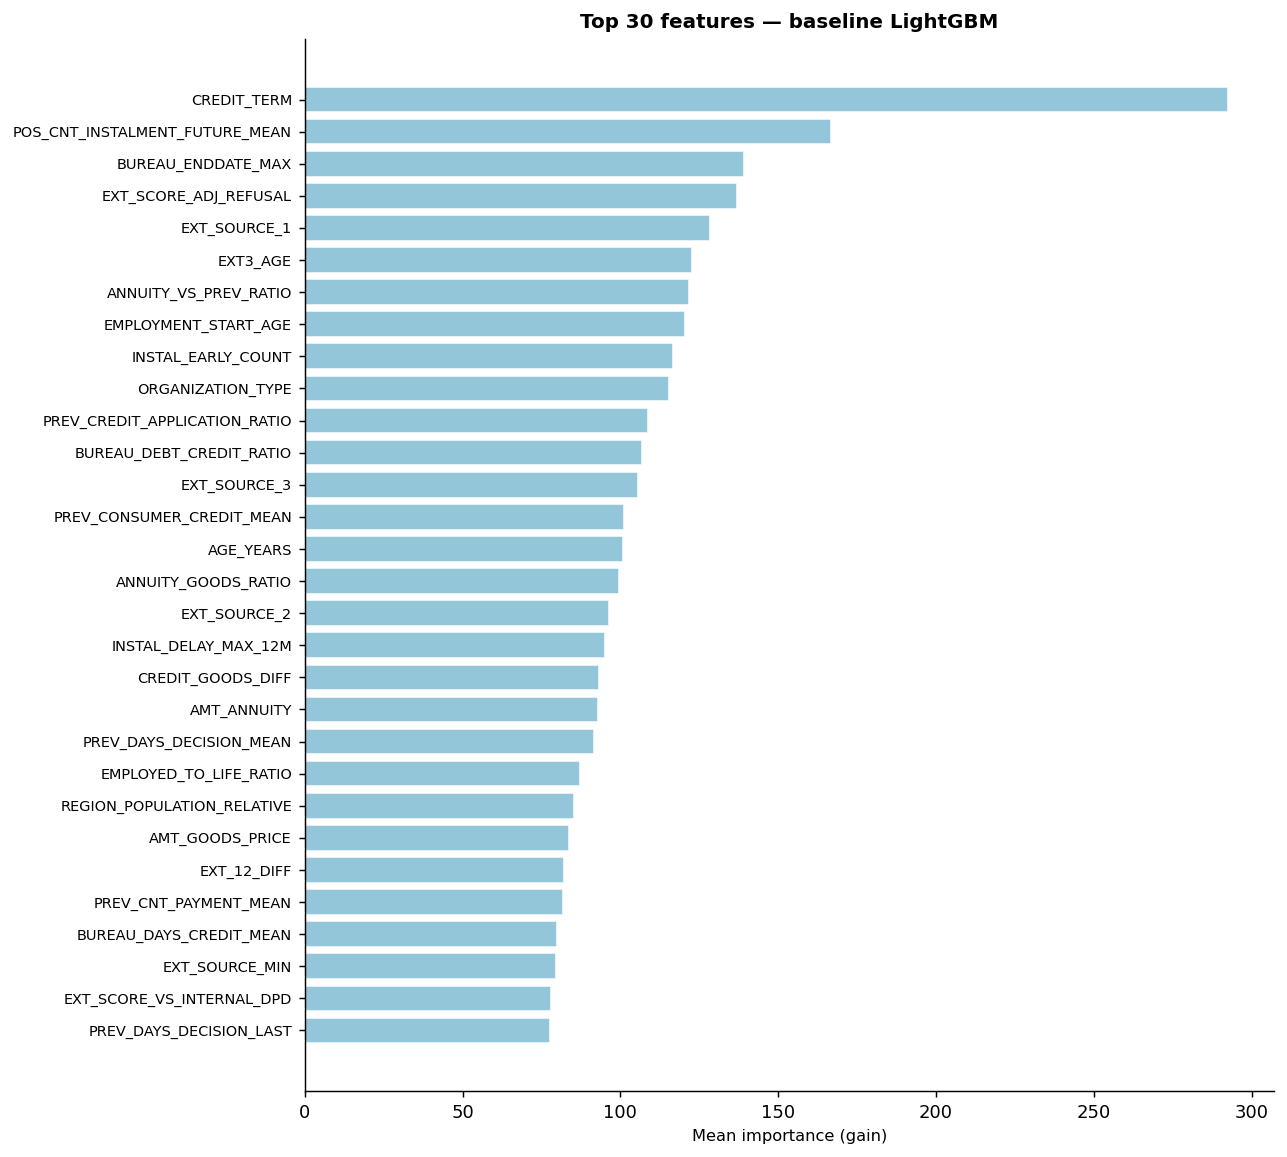


Top 10 features:
                       feature  mean_importance
                   CREDIT_TERM            292.4
POS_CNT_INSTALMENT_FUTURE_MEAN            166.8
            BUREAU_ENDDATE_MAX            139.2
         EXT_SCORE_ADJ_REFUSAL            137.0
                  EXT_SOURCE_1            128.4
                      EXT3_AGE            122.8
         ANNUITY_VS_PREV_RATIO            121.8
          EMPLOYMENT_START_AGE            120.4
            INSTAL_EARLY_COUNT            116.6
             ORGANIZATION_TYPE            115.4


In [ ]:
# ── Feature importance plot ───────────────────────────────────────────
feature_importances['mean_importance'] = feature_importances[
    [f'fold_{i}' for i in range(1, N_FOLDS + 1)]
].mean(axis=1)

feature_importances = feature_importances.sort_values(
    'mean_importance', ascending=False
).reset_index(drop=True)

# Top 30
top30 = feature_importances.head(30)

fig, ax = plt.subplots(figsize=(10, 9))
ax.barh(top30['feature'][::-1], top30['mean_importance'][::-1],
        color='#7fbcd2', alpha=0.85, edgecolor='white')
ax.set_xlabel("Mean importance (gain)", fontsize=9)
ax.set_title("Top 30 features — baseline LightGBM",
             fontsize=11, fontweight='bold')
ax.tick_params(axis='y', labelsize=8)
plt.tight_layout()
plt.savefig("baseline_feature_importance.png", bbox_inches='tight', dpi=150)
plt.show()

print("\nTop 10 features:")
print(feature_importances[['feature', 'mean_importance']].head(10).to_string(index=False))

In [ ]:
# ── Zero importance features ──────────────────────────────────────────
zero_importance = feature_importances[
    feature_importances['mean_importance'] == 0
]['feature'].tolist()

print(f"Features with zero importance: {len(zero_importance)}")
if zero_importance:
    print(zero_importance)

Features with zero importance: 18
['FLAG_CONT_MOBILE', 'FLAG_EMP_PHONE', 'BBAL_EVER_LATE_3M', 'BBAL_EVER_LATE', 'BUREAU_HAS_BAD_DEBT', 'BUREAU_EVER_OVERDUE', 'IS_NOT_EMPLOYED', 'EVER_LATE_ANY_PRODUCT', 'INCOME_PENSIONER', 'POS_EVER_LATE_30', 'INSTAL_EVER_LATE', 'POS_EVER_LATE_60', 'POS_EVER_LATE', 'HAS_ANY_DOCUMENT', 'CC_EVER_OVER_LIMIT', 'INSTAL_EVER_UNDERPAID', 'CREDIT_EXCEEDS_GOODS', 'CC_EVER_LATE']


In [ ]:
# ── Feature selection ─────────────────────────────────────────────────
DROP_FEATURES = zero_importance + ['PREV_INTEREST_RATE_MEAN']

FEATURE_COLS_SELECTED = [
    c for c in FEATURE_COLS
    if c not in DROP_FEATURES
]

# Rebuild X and X_test with selected features
X_sel      = X[FEATURE_COLS_SELECTED + TE_COLS].copy()
X_test_sel = X_test[FEATURE_COLS_SELECTED + TE_COLS].copy()

print(f"Features before selection : {len(FEATURE_COLS) + len(TE_COLS)}")
print(f"Features dropped          : {len(DROP_FEATURES)}")
print(f"Features after selection  : {len(FEATURE_COLS_SELECTED) + len(TE_COLS)}")

Features before selection : 266
Features dropped          : 19
Features after selection  : 247


In [ ]:
# ── Confirmation CV with selected features ────────────────────────────
# Reruns the same k-fold loop with X_sel instead of X
# to confirm dropping zero-importance features doesn't hurt AUC

oof_preds_sel  = np.zeros(len(X_sel))
fold_aucs_sel  = []

print(f"Confirmation CV — {len(FEATURE_COLS_SELECTED) + len(TE_COLS)} features\n")
print(f"{'Fold':<6} {'AUC':>8}  {'vs baseline':>12}")
print("─" * 32)

for fold, (train_idx, val_idx) in enumerate(skf.split(X_sel, y), 1):

    X_tr, X_val = X_sel.iloc[train_idx].copy(), X_sel.iloc[val_idx].copy()
    y_tr, y_val = y.iloc[train_idx],             y.iloc[val_idx]

    X_tr, X_val, _ = target_encode(X_tr, y_tr, X_val, cols=TE_COLS)

    model = lgb.LGBMClassifier(**BASELINE_PARAMS)
    model.fit(
        X_tr, y_tr,
        eval_set=[(X_val, y_val)],
        callbacks=[
            lgb.early_stopping(stopping_rounds=50, verbose=False),
            lgb.log_evaluation(period=-1)
        ]
    )

    oof_preds_sel[val_idx] = model.predict_proba(X_val)[:, 1]
    fold_auc = roc_auc_score(y_val, oof_preds_sel[val_idx])
    fold_aucs_sel.append(fold_auc)

    delta = fold_auc - fold_aucs[fold - 1]
    print(f"  {fold:<4} {fold_auc:>8.5f}  {delta:>+12.5f}")

oof_auc_sel = roc_auc_score(y, oof_preds_sel)
delta_oof   = oof_auc_sel - oof_auc

print(f"\n{'─' * 32}")
print(f"  OOF AUC (selected) : {oof_auc_sel:.5f}")
print(f"  OOF AUC (baseline) : {oof_auc:.5f}")
print(f"  Delta              : {delta_oof:+.5f}")
print(f"\n{'Proceed to tuning ✓' if delta_oof >= -0.001 else 'Warning — AUC dropped > 0.001, review dropped features'}")

Confirmation CV — 247 features

Fold        AUC   vs baseline
────────────────────────────────
  1     0.78864      +0.00015
  2     0.78402      -0.00000
  3     0.79088      +0.00023
  4     0.78573      +0.00000
  5     0.78562      +0.00024

────────────────────────────────
  OOF AUC (selected) : 0.78692
  OOF AUC (baseline) : 0.78680
  Delta              : +0.00013

Proceed to tuning ✓


## Hyperparameter Tuning — Optuna

Bayesian optimisation with 50 trials on a 20% stratified sample (3-fold CV).
Sampling 20% of the data per trial reduces search time from ~5 hours to ~30
minutes while preserving relative parameter rankings.

Final validation uses the full dataset with 5-fold CV.

**Results:**

| Fold | AUC | vs baseline |
|---|---|---|
| 1 | 0.79215 | +0.00351 |
| 2 | 0.78772 | +0.00370 |
| 3 | 0.79530 | +0.00442 |
| 4 | 0.79044 | +0.00471 |
| 5 | 0.78751 | +0.00189 |
| **OOF AUC** | **0.79061** | **+0.00369** | 

In [ ]:
import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 419.5/419.5 kB 11.5 MB/s eta 0:00:0000:01


In [ ]:
# Use 20% of train data inside Optuna trials — fast proxy for full AUC
# Final 5-fold CV always runs on full data
SAMPLE_IDX = np.random.RandomState(42).choice(
    len(X_sel), size=int(len(X_sel) * 0.2), replace=False
)
X_sel_sample = X_sel.iloc[SAMPLE_IDX].reset_index(drop=True)
y_sample     = y.iloc[SAMPLE_IDX].reset_index(drop=True)

def objective(trial):
    params = {
        'objective':         'binary',
        'metric':            'auc',
        'scale_pos_weight':  SCALE_POS_WEIGHT,
        'random_state':      42,
        'n_jobs':            -1,
        'verbose':           -1,
        'num_leaves':        trial.suggest_int('num_leaves', 20, 150),
        'max_depth':         trial.suggest_int('max_depth', 3, 12),
        'min_child_samples': trial.suggest_int('min_child_samples', 20, 200),
        'reg_alpha':         trial.suggest_float('reg_alpha', 1e-4, 10.0, log=True),
        'reg_lambda':        trial.suggest_float('reg_lambda', 1e-4, 10.0, log=True),
        'min_split_gain':    trial.suggest_float('min_split_gain', 0.0, 1.0),
        'subsample':         trial.suggest_float('subsample', 0.5, 1.0),
        'colsample_bytree':  trial.suggest_float('colsample_bytree', 0.5, 1.0),
        'subsample_freq':    trial.suggest_int('subsample_freq', 1, 10),
        'learning_rate':     0.05,
        'n_estimators':      500,    # lower cap — faster trials
    }

    skf_opt = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)
    fold_aucs_trial = []

    for train_idx, val_idx in skf_opt.split(X_sel_sample, y_sample):
        X_tr  = X_sel_sample.iloc[train_idx].copy()
        X_val = X_sel_sample.iloc[val_idx].copy()
        y_tr  = y_sample.iloc[train_idx]
        y_val = y_sample.iloc[val_idx]

        X_tr, X_val, _ = target_encode(X_tr, y_tr, X_val, cols=TE_COLS)

        model = lgb.LGBMClassifier(**params)
        model.fit(
            X_tr, y_tr,
            eval_set=[(X_val, y_val)],
            callbacks=[
                lgb.early_stopping(stopping_rounds=30, verbose=False),
                lgb.log_evaluation(period=-1)
            ]
        )
        fold_aucs_trial.append(
            roc_auc_score(y_val, model.predict_proba(X_val)[:, 1])
        )

    return np.mean(fold_aucs_trial)

# Rerun study with 50 trials on 20% sample
study = optuna.create_study(
    direction='maximize',
    sampler=optuna.samplers.TPESampler(seed=42)
)
study.optimize(objective, n_trials=50, show_progress_bar=True)

print(f"\nBest AUC (sampled 3-fold) : {study.best_value:.5f}")
print("Best params:")
for k, v in study.best_params.items():
    print(f"  {k:<25}: {v}")

  0%|          | 0/50 [00:00<?, ?it/s]


Best AUC (sampled 3-fold) : 0.77642
Best params:
  num_leaves               : 37
  max_depth                : 3
  min_child_samples        : 192
  reg_alpha                : 8.49756851708601
  reg_lambda               : 0.05595906137623619
  min_split_gain           : 0.49604131216971425
  subsample                : 0.6178606265353372
  colsample_bytree         : 0.7599422688766206
  subsample_freq           : 3


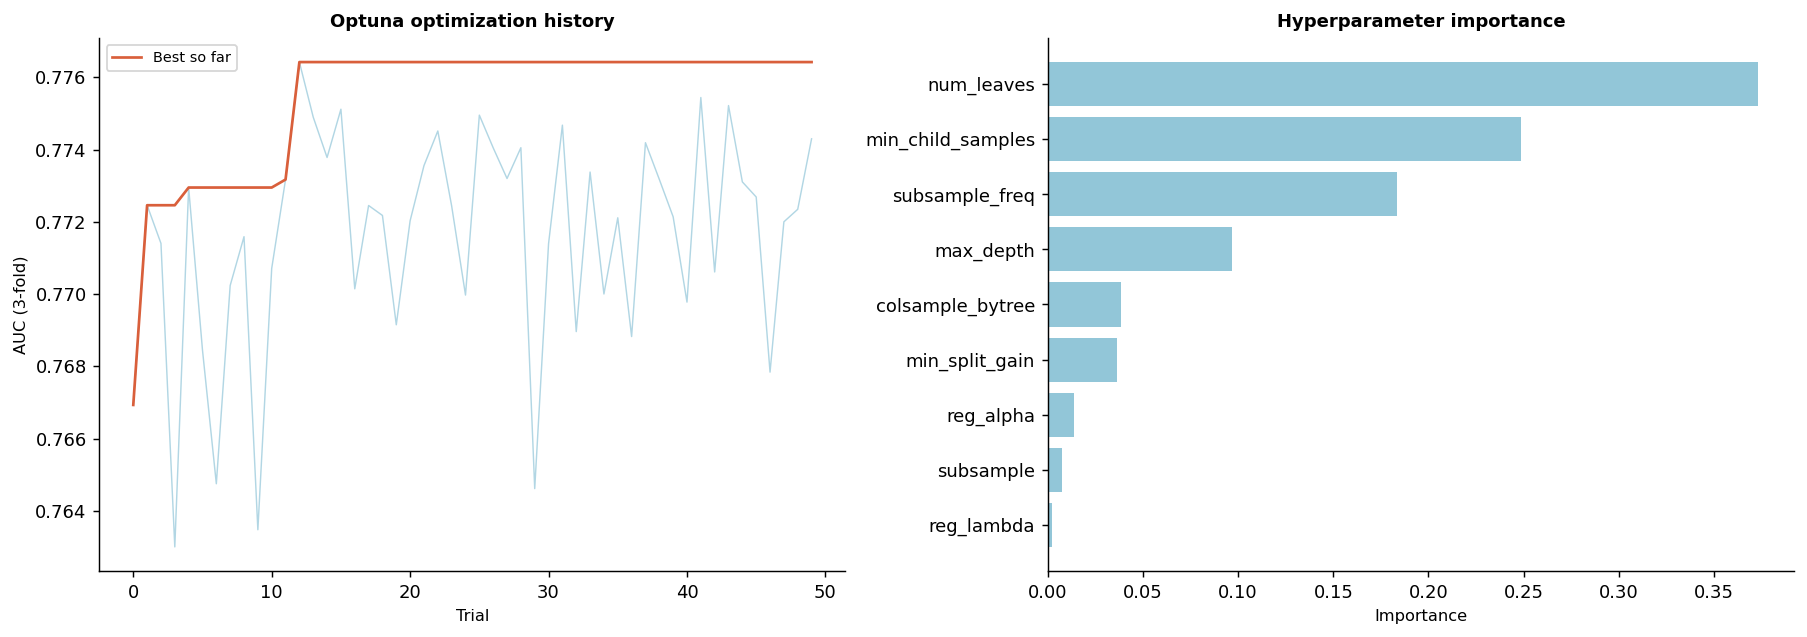

In [ ]:
# ── Optuna results plot ───────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Optimization history
trials_df = study.trials_dataframe()
axes[0].plot(trials_df['number'], trials_df['value'],
             color='#7fbcd2', linewidth=0.8, alpha=0.6)
axes[0].plot(trials_df['number'],
             trials_df['value'].cummax(),
             color='#d95f3b', linewidth=1.5, label='Best so far')
axes[0].set_xlabel("Trial", fontsize=9)
axes[0].set_ylabel("AUC (3-fold)", fontsize=9)
axes[0].set_title("Optuna optimization history", fontsize=10, fontweight='bold')
axes[0].legend(fontsize=8)

# Parameter importance
importances = optuna.importance.get_param_importances(study)
axes[1].barh(list(importances.keys())[::-1],
             list(importances.values())[::-1],
             color='#7fbcd2', alpha=0.85)
axes[1].set_xlabel("Importance", fontsize=9)
axes[1].set_title("Hyperparameter importance", fontsize=10, fontweight='bold')

plt.tight_layout()
plt.savefig("optuna_results.png", bbox_inches='tight', dpi=150)
plt.show()

In [ ]:
# ── Final CV with best params ─────────────────────────────────────────
# Rerun full 5-fold with tuned params to get reliable AUC estimate

TUNED_PARAMS = {
    'objective':        'binary',
    'metric':           'auc',
    'scale_pos_weight': SCALE_POS_WEIGHT,
    'random_state':     42,
    'n_jobs':           -1,
    'verbose':          -1,
    'learning_rate':    0.05,
    'n_estimators':     2000,     # higher — early stopping will find optimum
    **study.best_params
}

oof_preds_tuned  = np.zeros(len(X_sel))
test_preds_tuned = np.zeros(len(X_test_sel))
fold_aucs_tuned  = []

print(f"Final 5-fold CV with tuned params\n")
print(f"{'Fold':<6} {'AUC':>8}  {'vs selected baseline':>22}")
print("─" * 42)

for fold, (train_idx, val_idx) in enumerate(skf.split(X_sel, y), 1):

    X_tr  = X_sel.iloc[train_idx].copy()
    X_val = X_sel.iloc[val_idx].copy()
    y_tr  = y.iloc[train_idx]
    y_val = y.iloc[val_idx]

    # Target encode — fit on train fold only
    X_tr, X_val, te_enc = target_encode(X_tr, y_tr, X_val, cols=TE_COLS)

    # Train
    model = lgb.LGBMClassifier(**TUNED_PARAMS)
    model.fit(
        X_tr, y_tr,
        eval_set=[(X_val, y_val)],
        callbacks=[
            lgb.early_stopping(stopping_rounds=100, verbose=False),
            lgb.log_evaluation(period=-1)
        ]
    )

    # OOF predictions
    oof_preds_tuned[val_idx] = model.predict_proba(X_val)[:, 1]
    fold_auc = roc_auc_score(y_val, oof_preds_tuned[val_idx])
    fold_aucs_tuned.append(fold_auc)

    # ── Test predictions ────────────────────────────────────
    # Apply THIS fold's encoding to test, predict with THIS fold's model,
    # accumulate and average across all folds.
    # Each fold contributes equally and independently to the final test prediction.
    X_test_enc = X_test_sel.copy()
    for col in TE_COLS:
        X_test_enc[col] = X_test_enc[col].map(
            te_enc[col]['mapping']          # ← this fold's mapping
        ).fillna(te_enc[col]['global_mean'])

    test_preds_tuned += model.predict_proba(X_test_enc)[:, 1] / N_FOLDS

    delta = fold_auc - fold_aucs_sel[fold - 1]
    print(f"  {fold:<4} {fold_auc:>8.5f}  {delta:>+22.5f}")

oof_auc_tuned = roc_auc_score(y, oof_preds_tuned)
print(f"\n{'─' * 42}")
print(f"  OOF AUC (tuned)    : {oof_auc_tuned:.5f}")
print(f"  OOF AUC (baseline) : {oof_auc_sel:.5f}")
print(f"  Delta              : {oof_auc_tuned - oof_auc_sel:+.5f}")

Final 5-fold CV with tuned params

Fold        AUC    vs selected baseline
──────────────────────────────────────────
  1     0.79215                +0.00351
  2     0.78772                +0.00370
  3     0.79530                +0.00442
  4     0.79044                +0.00471
  5     0.78751                +0.00189

──────────────────────────────────────────
  OOF AUC (tuned)    : 0.79061
  OOF AUC (baseline) : 0.78692
  Delta              : +0.00369


## Model Interpretation — SHAP Analysis

SHAP (SHapley Additive exPlanations) assigns each feature a contribution
value for every individual prediction. Positive SHAP = pushes toward default,
negative SHAP = pushes away from default. Color encodes feature value:
red = high, blue = low.

---


### Three takeaways for business stakeholders

1. **All SHAP directions are consistent with credit risk domain knowledge** —
   higher external scores reduce risk, more debt relative to income increases
   risk, higher education reduces risk. A model where SHAP directions
   contradict domain knowledge would indicate data leakage or a bug.

2. **Individual predictions are fully explainable** — the waterfall plots
   show exactly which features drove the model's decision for any specific
   client, enabling actionable feedback to loan officers.

3. **The model captures non-linear relationships** that rule-based scorecards
   and logistic regression models miss — particularly the interaction between
   external scores and internal behaviour history.## SHAP

In [ ]:
import shap

In [ ]:
# ── Train a single model on full train for SHAP ───────────────────────
# SHAP on the full 5-fold ensemble is complex — we use a single model
# trained on 80% of data for interpretation purposes.
# This is standard practice — SHAP is for explanation, not evaluation.

from sklearn.model_selection import train_test_split

X_shap_tr, X_shap_val, y_shap_tr, y_shap_val = train_test_split(
    X_sel, y, test_size=0.2, random_state=42, stratify=y
)

# Target encode on this split
X_shap_tr, X_shap_val, te_shap = target_encode(
    X_shap_tr, y_shap_tr, X_shap_val, cols=TE_COLS
)

shap_model = lgb.LGBMClassifier(**TUNED_PARAMS)
shap_model.fit(
    X_shap_tr, y_shap_tr,
    eval_set=[(X_shap_val, y_shap_val)],
    callbacks=[
        lgb.early_stopping(stopping_rounds=100, verbose=False),
        lgb.log_evaluation(period=-1)
    ]
)

shap_auc = roc_auc_score(y_shap_val,
                          shap_model.predict_proba(X_shap_val)[:, 1])
print(f"Single model AUC (80/20 split): {shap_auc:.5f}")

Single model AUC (80/20 split): 0.79200


In [ ]:
# ── Compute SHAP values ───────────────────────────────────────────────
# Sample 5000 rows for speed — sufficient for reliable SHAP estimates

SHAP_SAMPLE = 5000
shap_sample_idx = np.random.RandomState(42).choice(
    len(X_shap_val), size=min(SHAP_SAMPLE, len(X_shap_val)), replace=False
)
X_shap_sample = X_shap_val.iloc[shap_sample_idx]

explainer   = shap.TreeExplainer(shap_model)
shap_values = explainer.shap_values(X_shap_sample)

# LightGBM binary returns list [neg_class, pos_class] — take positive class
if isinstance(shap_values, list):
    shap_values = shap_values[1]

print(f"SHAP values computed — shape: {shap_values.shape}")

SHAP values computed — shape: (5000, 247)


### SHAP Summary Plot

**The two most important features are engineered cross-table features —
not raw data columns.** This is the direct return on investment of the
feature engineering phase.

**`EXT_SCORE_VS_INTERNAL_DPD` — #1**  
Combines external credit score with internal DPD history. Low values push
strongly toward default. The wide horizontal spread confirms it is the single
most discriminating feature in the model.

**`EXT_SCORE_ADJ_REFUSAL` — #2**  
Adjusts the external score downward based on HC's own refusal history.
Same direction as above — low values signal high risk.

**`IS_MALE` — #3**  
Males (red) carry higher default risk than females (blue) in this dataset,
consistent with credit risk literature. Clean binary separation.

**`EXT_SOURCE_MEAN` — #4**  
Low external scores consistently predict default. Tight spread indicates
uniform predictive power across all client segments.

**`CREDIT_TERM` — #6**  
Shows a non-linear U-shape: both very short and very long loan terms
increase default risk, with the safest clients in the middle range.
A logistic regression would miss this relationship entirely — one of the
key advantages of gradient boosting on tabular data.

**`ANNUITY_VS_PREV_RATIO` — #8**  
High values (current annuity much higher than historical average) push
toward default — clients overextending relative to their past behaviour.
Designed specifically to capture this cross-table signal.

**`INSTAL_DELAY_MAX_12M` — #22**  
High recent delays push strongly toward default. The 12-month recency
window is more predictive than the full historical average, confirming
that recent behaviour outweighs distant history.

**`POS_MONTHS_COUNT` — #19 (grey)**  
Mostly grey — missing for clients with no POS history. LightGBM uses
the missingness itself as a split criterion, making NULL informative
rather than problematic.

---

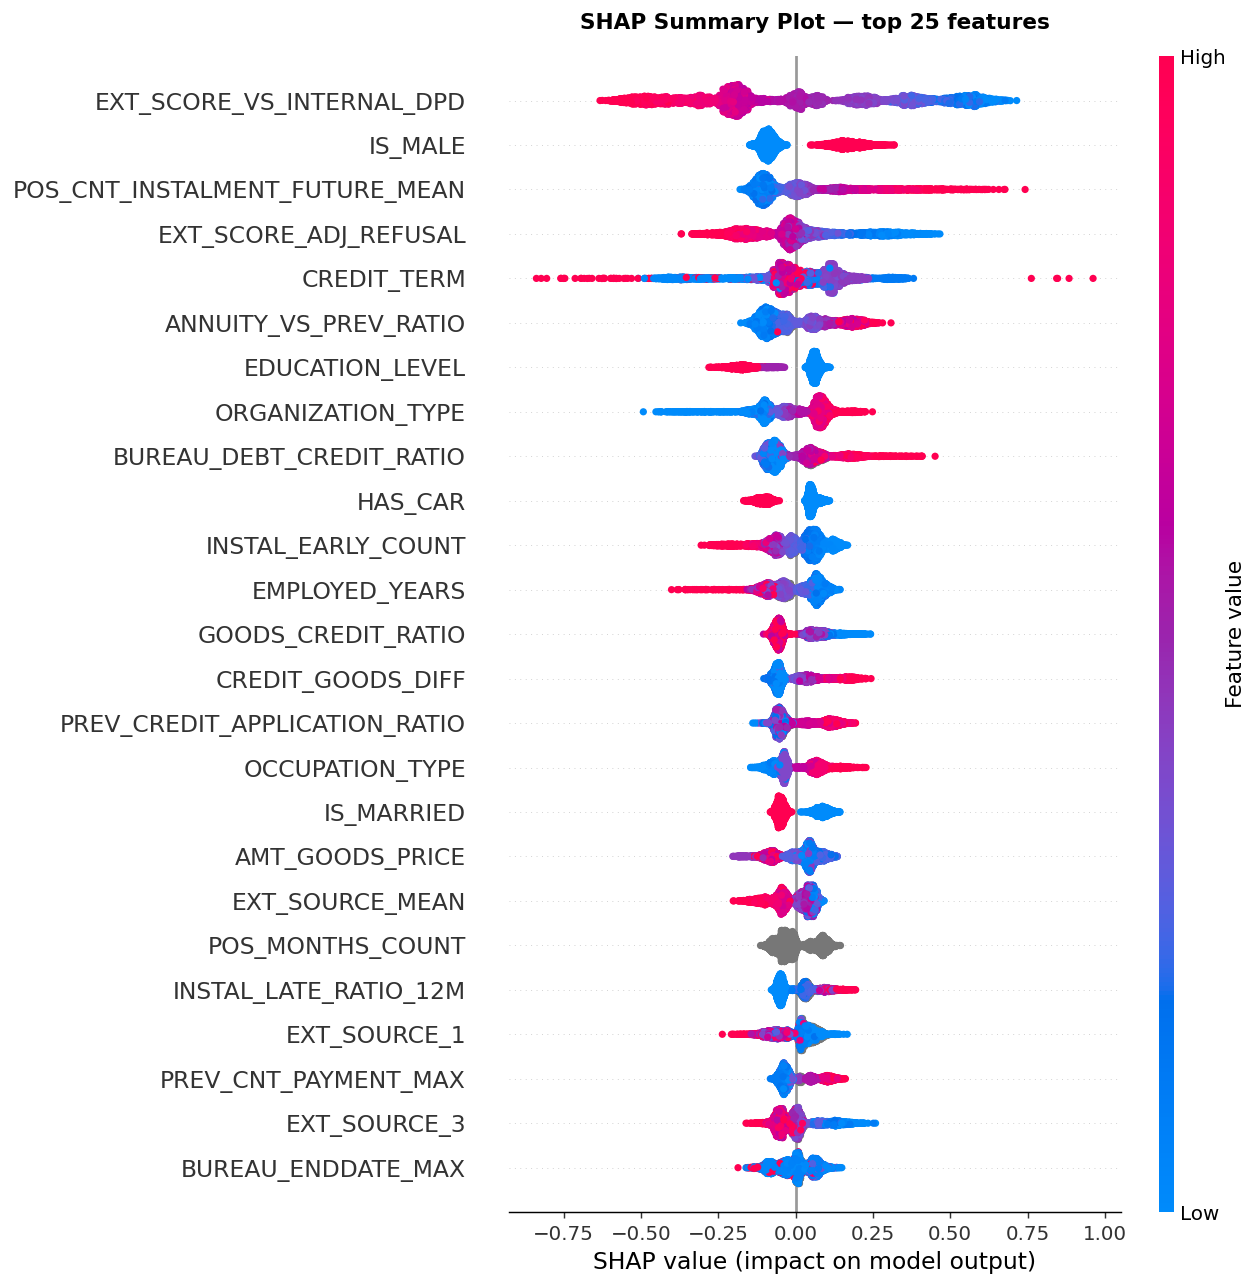

In [ ]:
# ── Plot 1 — SHAP summary plot (beeswarm) ────────────────────────────
# Best plot for a portfolio — shows both importance AND direction of effect
# Red = high feature value, Blue = low feature value
# X axis = impact on model output (positive = pushes toward default)

plt.figure(figsize=(10, 10))
shap.summary_plot(
    shap_values,
    X_shap_sample,
    max_display=25,
    show=False,
    plot_size=None
)
plt.title("SHAP Summary Plot — top 25 features",
          fontsize=12, fontweight='bold', pad=15)
plt.tight_layout()
plt.savefig("shap_summary.png", bbox_inches='tight', dpi=150)
plt.show()

### Mean Absolute SHAP

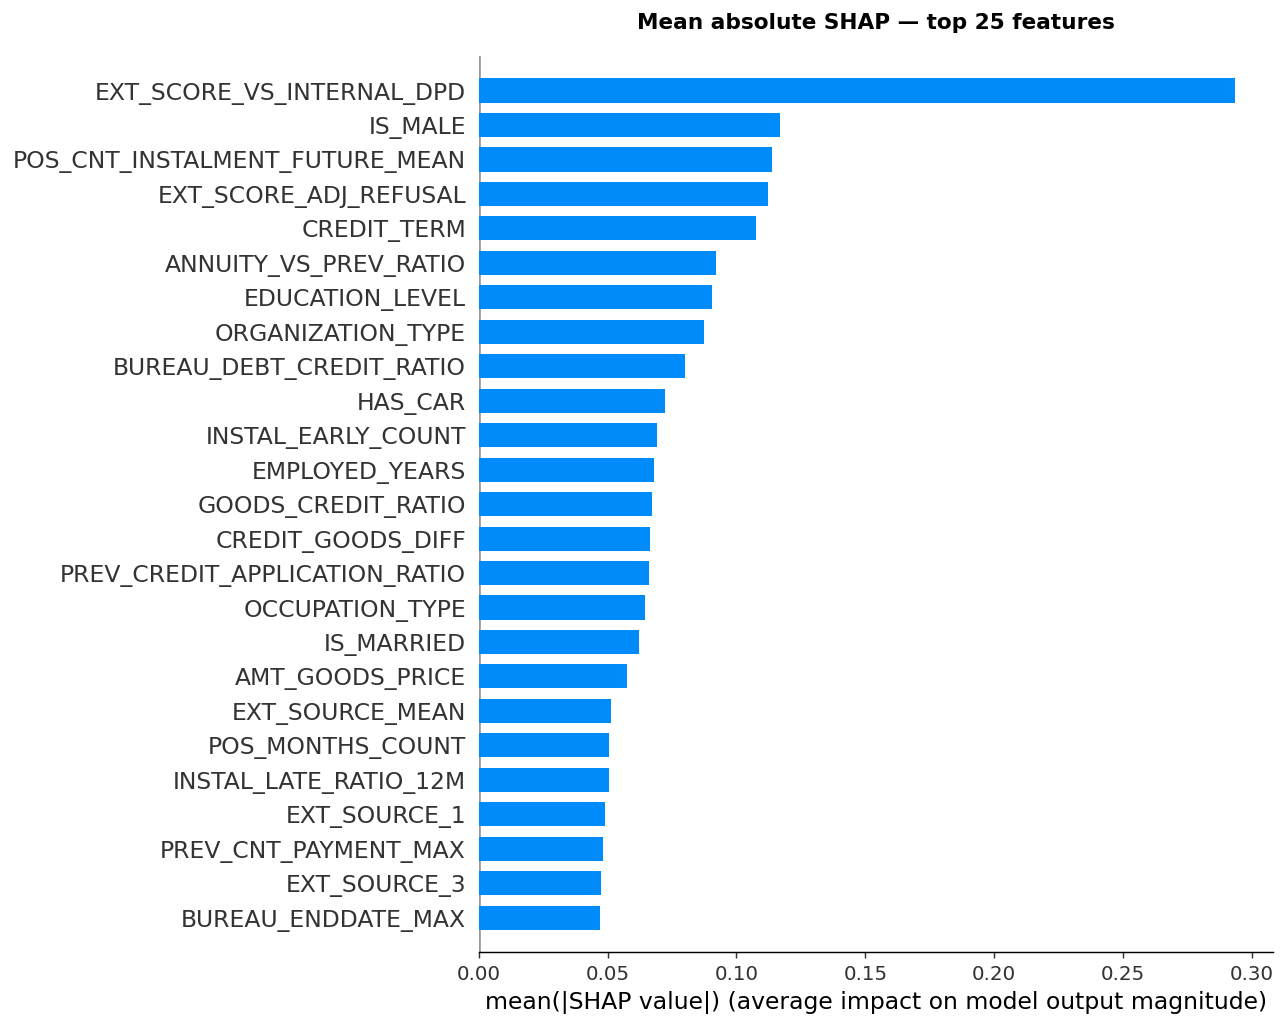

In [ ]:
# ── Plot 2 — SHAP bar plot (mean absolute SHAP) ───────────────────────
# Clean version for presentations — pure importance ranking

plt.figure(figsize=(10, 8))
shap.summary_plot(
    shap_values,
    X_shap_sample,
    plot_type='bar',
    max_display=25,
    show=False,
    plot_size=None
)
plt.title("Mean absolute SHAP — top 25 features",
          fontsize=12, fontweight='bold', pad=15)
plt.tight_layout()
plt.savefig("shap_bar.png", bbox_inches='tight', dpi=150)
plt.show()

### Dependence Plot

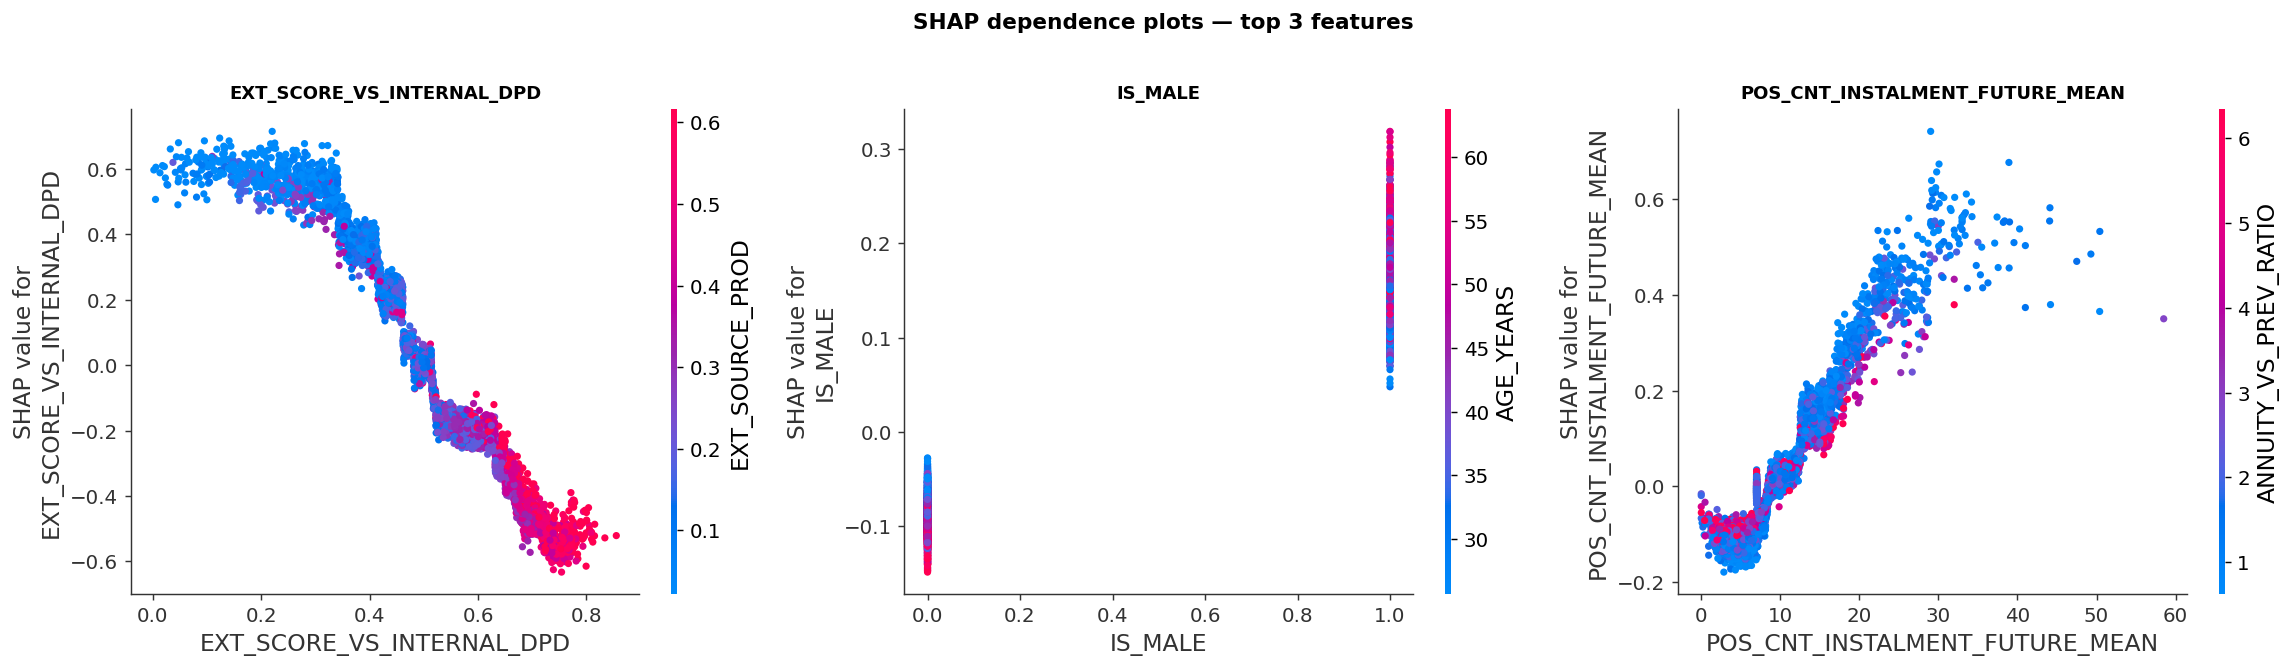

In [ ]:
# ── Plot 3 — SHAP dependence plots for top 3 features ────────────────
# Shows the non-linear relationship between feature value and its SHAP value
# The color dimension shows interaction with the most correlated feature

# Robust handling for potential 'NAType' errors in SHAP plots.
# The error "TypeError: float() argument must be a string or a real number, not 'NAType'"
# indicates that pandas.NaT values are still present in X_shap_sample when SHAP tries
# to convert values to float. This can happen if NaT values exist in object columns
# or if previous coercion methods weren't fully effective in all cases.

# Step 1: Explicitly replace all pandas.NaT values with numpy.nan
# This ensures that any 'Not a Time' values are converted to standard missing numerical values.
X_shap_sample = X_shap_sample.replace({pd.NaT: np.nan})

# Step 2: Convert all columns to float if they are numeric.
# This is crucial to ensure that all numerical columns can handle potential float medians
# and np.nan values, preventing the TypeError with Int64Dtype.
for col in X_shap_sample.columns:
    # Check if the column is already numeric (int, float, etc.) or if it can be converted to numeric.
    if pd.api.types.is_numeric_dtype(X_shap_sample[col]):
        # Convert to float. This will convert any integer dtype (like int64 or Int64) to float64,
        # and `pd.NA` will become `np.nan`.
        X_shap_sample[col] = X_shap_sample[col].astype(float)
    else:
        # If it's an object column or other non-numeric, try to convert it to numeric.
        # This will convert strings representing numbers to floats and non-convertible values to NaN.
        X_shap_sample[col] = pd.to_numeric(X_shap_sample[col], errors='coerce')

# Step 3: Fill any remaining NaN values with the median.
# Now that all numeric columns are float dtype, this operation should be safe.
X_shap_sample = X_shap_sample.fillna(X_shap_sample.median())

top3_features = pd.DataFrame({
    'feature':    X_shap_sample.columns,
    'mean_shap':  np.abs(shap_values).mean(axis=0)
}).sort_values('mean_shap', ascending=False).head(3)['feature'].tolist()

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, feat in zip(axes, top3_features):
    feat_idx = list(X_shap_sample.columns).index(feat)
    shap.dependence_plot(
        feat_idx,
        shap_values,
        X_shap_sample, # Use the cleaned X_shap_sample here
        ax=ax,
        show=False
    )
    ax.set_title(feat, fontsize=10, fontweight='bold')
    ax.spines[['top', 'right']].set_visible(False)

plt.suptitle("SHAP dependence plots — top 3 features",
             fontsize=12, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig("shap_dependence.png", bbox_inches='tight', dpi=150)
plt.show()

### Waterfall Plots

Waterfall plots explain individual predictions by showing how each feature
pushes the model output above or below the baseline (expected value).
Red bars increase the predicted default probability, blue bars decrease it.
The baseline `E[f(X)] = -0.625` corresponds to the global average prediction
in log-odds space (~8% default rate).

---

#### True Positive — correctly identified defaulter (72.6% predicted probability)

The model correctly flags this client as high risk. The dominant driver is
`EXT_SCORE_VS_INTERNAL_DPD = 0.303` (+0.48) — a low value indicating both
a poor external credit score and a history of internal DPD at Home Credit.
Supporting risk signals include `BUREAU_DEBT_CREDIT_RATIO = 0.929` (+0.15),
meaning 93% of total credit is still outstanding, `CC_UTILIZATION_MEAN_12M = 0.869`
(+0.15) confirming near-limit credit card usage, and a large cash-out component
on the current loan (`CREDIT_GOODS_DIFF` +0.15). The only protective factor
is young age (-0.20), which is insufficient to offset the financial stress signals.

---

#### False Negative — defaulter the model missed (22.2% predicted probability)

This is the more instructive case. The model assigns low risk because the client
looks reliable on paper: a high `EXT_SCORE_VS_INTERNAL_DPD = 0.668` (-0.37)
indicates a good external bureau score with clean internal DPD history,
27 years of stable employment (-0.15), and a current loan burden consistent
with historical behaviour (`ANNUITY_VS_PREV_RATIO ≈ 1.0`, -0.13).
The only risk signals — `CREDIT_TERM` (+0.34) and `POS_DPD_DEF_MEAN` (+0.21)
— are not enough to override the positive signals.

This client likely defaulted due to an unforeseen event (job loss, health issue)
that no historical feature could anticipate. This represents **irreducible error** —
the fundamental limit of any model that predicts future behaviour from past data.
Understanding where and why the model fails is as important as knowing where it succeeds.

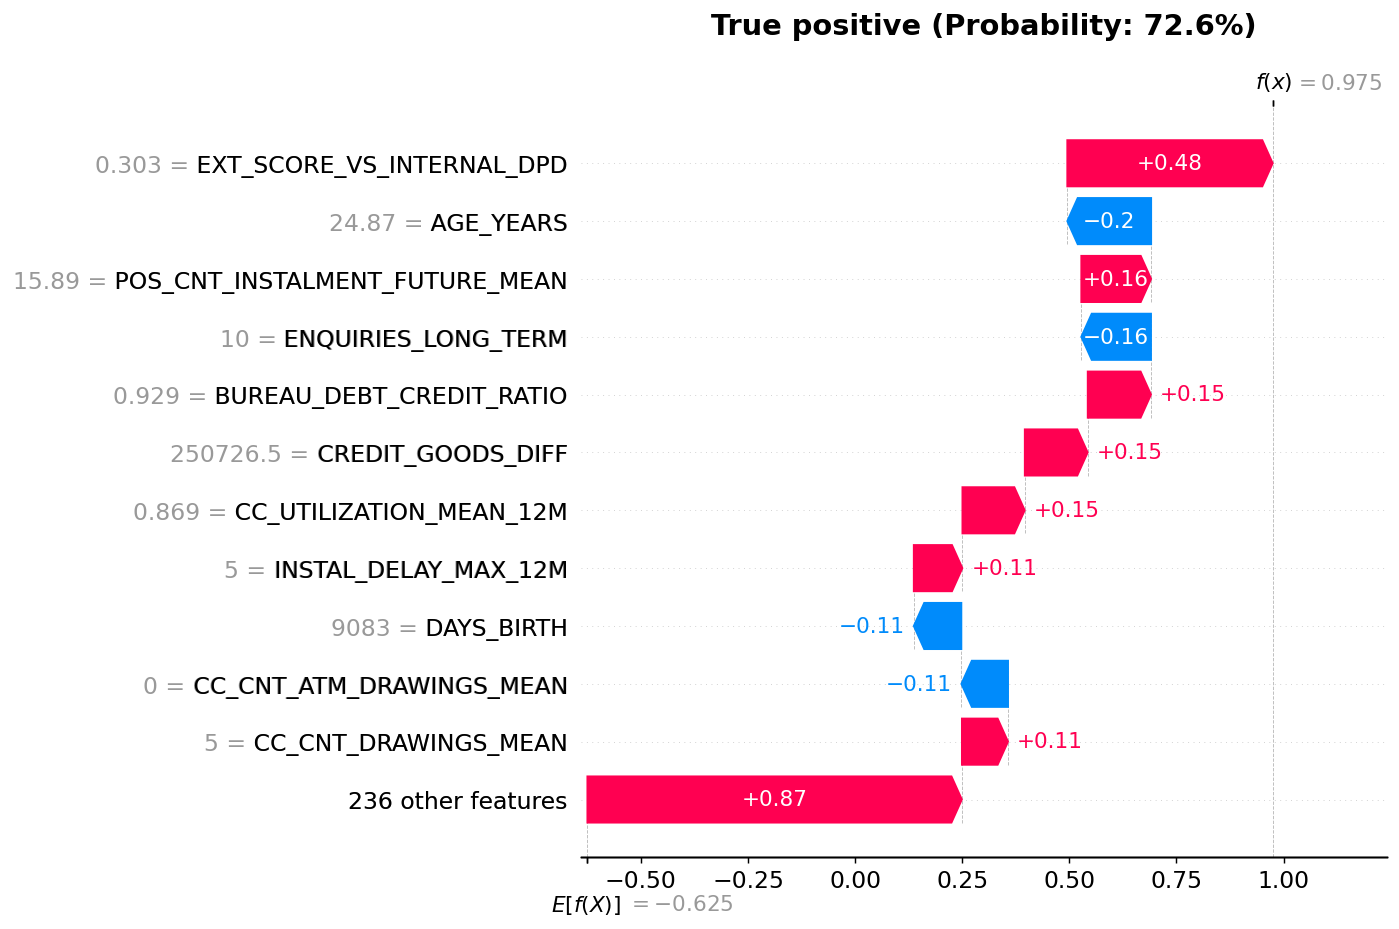

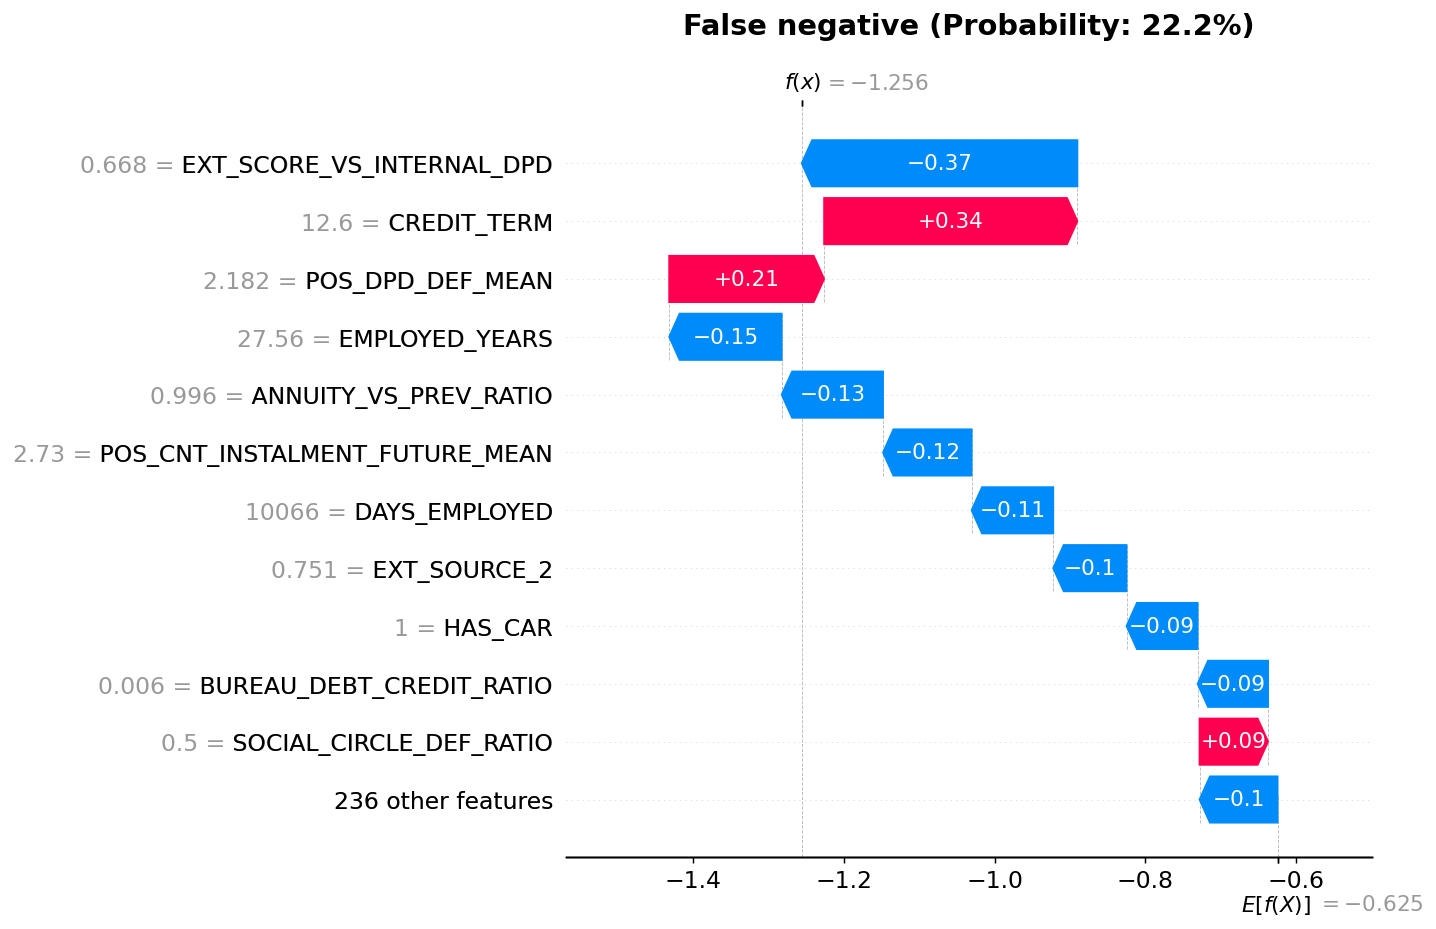

In [ ]:
import matplotlib.pyplot as plt
import shap
import pandas as pd
import numpy as np
from scipy.special import expit # For calculating probabilities from log-odds
# 1. Works only on sample used for SHAP values — ensures alignment between data, SHAP values, and predictions
# Ensure X_shap_sample and y_shap_sample are aligned and correspond to the same rows used for SHAP calculation
y_shap_sample = y_shap_val.loc[X_shap_sample.index]

# Calculate predicted probabilities for the SHAP sample using the same model
preds_sample = shap_model.predict_proba(X_shap_sample)[:, 1]

val_results = pd.DataFrame({
    'true':  y_shap_sample.values,
    'pred':  preds_sample,
    'idx':   range(len(X_shap_sample)) # Indice posizionale (0, 1, 2...)
})

# 2. Find the correct indices
# True positive (real = 1, prob > 0.7)
tp_candidates = val_results[(val_results['true'] == 1) & (val_results['pred'] > 0.7)]
if tp_candidates.empty:
    print("Attention: No true positive with prob > 0.7 found in the sample!")
else:
    tp_idx = tp_candidates.iloc[0]['idx']

# False negative (real = 1, prob < 0.2)
fn_candidates = val_results[(val_results['true'] == 1) & (val_results['pred'] < 0.2)]
if fn_candidates.empty:
    print("Attention: No false negative with prob < 0.2 found in the sample!")
else:
    fn_idx = fn_candidates.iloc[0]['idx']

# 3. base_val and shap_values for class 1
base_val = explainer.expected_value
if isinstance(base_val, list) or isinstance(base_val, np.ndarray):
    base_val = base_val[1]

# If shap_values is a list (array for class 0, array for class 1), select class 1
if isinstance(shap_values, list):
    shap_vals_class1 = shap_values[1]
else:
    shap_vals_class1 = shap_values

# 4. Truncate feature names for better display in waterfall plot
clean_feature_names = [f[:32] + '...' if len(f) > 35 else f for f in X_shap_sample.columns]

# 5. Plot True Positive 
plt.figure(figsize=(10, 8))
shap_exp_tp = shap.Explanation(
    values        = shap_vals_class1[int(tp_idx)], 
    base_values   = base_val,
    data          = X_shap_sample.iloc[int(tp_idx)].values,
    feature_names = clean_feature_names
)
shap.waterfall_plot(shap_exp_tp, max_display=12, show=False)

# Add probability to title
prob_tp = expit(shap_exp_tp.values.sum() + base_val)
plt.title(f"True positive (Probability: {prob_tp:.1%})", fontsize=16, fontweight='bold', pad=20)
plt.show()

# ─── Plot False Negative ─────────────────────────────────────────
plt.figure(figsize=(10, 8))
shap_exp_fn = shap.Explanation(
    values        = shap_vals_class1[int(fn_idx)], 
    base_values   = base_val,
    data          = X_shap_sample.iloc[int(fn_idx)].values,
    feature_names = clean_feature_names
)
shap.waterfall_plot(shap_exp_fn, max_display=12, show=False)

# Add probability to title
prob_fn = expit(shap_exp_fn.values.sum() + base_val)
plt.title(f"False negative (Probability: {prob_fn:.1%})", fontsize=16, fontweight='bold', pad=20)
plt.savefig("shap_waterfall_FN.png", bbox_inches='tight', dpi=150)
plt.show()
plt.close()

## Ensembling — Stacking with Meta-Learner

A single well-tuned LightGBM model already achieves strong performance.
Stacking combines three models with different inductive biases to extract
signal that no single algorithm captures alone.

---

### Architecture

**Stage 1 — Base models (5-fold CV each):**
- **LightGBM** — gradient boosting with leaf-wise tree growth, tuned via Optuna
- **XGBoost** — gradient boosting with level-wise tree growth, different regularisation structure
- **CatBoost** — gradient boosting with symmetric trees and built-in ordered boosting

Each model produces out-of-fold predictions on train and averaged predictions
on test. Target encoding is fitted independently inside each fold for all three
models — no leakage between folds or between stages.

**Stage 2 — Meta-learner (Logistic Regression):**
Trained on the OOF predictions from the three base models.
Logistic regression is the correct choice here — with only 3 input features,
any more complex meta-learner would overfit immediately.

---

### Results

| Model | OOF AUC |
|---|---|
| LightGBM | 0.79061 |
| XGBoost | 0.78769 |
| CatBoost | 0.78875 |
| Simple blend (equal weights) | 0.79142 |
| **Stacking (meta-learner)** | **0.79165** |

**Meta-learner weights:**

| Model | Weight |
|---|---|
| LightGBM | 0.587 |
| CatBoost | 0.340 |
| XGBoost | 0.184 |

LightGBM receives the highest weight — consistent with it being the
best individual model and having been explicitly tuned via Optuna.
CatBoost contributes meaningfully despite lower individual AUC,
suggesting its errors are partially uncorrelated with LightGBM's —
exactly the condition that makes stacking effective.
XGBoost adds modest diversification.

---

### Progressive improvement — full pipeline summary

| Stage | OOF AUC | Delta |
|---|---|---|
| Baseline LightGBM (266 features) | 0.78680 | — |
| Feature selection (247 features) | 0.78692 | +0.00012 |
| Hyperparameter tuning | 0.79061 | +0.00369 |
| Simple blend | 0.79142 | +0.00081 |
| **Stacking** | **0.79165** | **+0.00023** |
| **Total gain** | | **+0.00485** |

The largest single gain came from hyperparameter tuning (+0.00369).
Ensembling added a further +0.00104 on top — modest but consistent,
and meaningful at the precision level of Kaggle leaderboard rankings.
The final submission uses stacking predictions as they marginally
outperformed the simple blend on OOF evaluation.

In [ ]:
import xgboost as xgb
import catboost as cb

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.1/97.1 MB 5.7 MB/s eta 0:00:00:00:0100:01


In [ ]:
# ── Base model parameters ─────────────────────────────────────────────
# Each algorithm has different inductive biases — their errors are
# partially uncorrelated, which is what makes stacking effective.

LGBM_PARAMS = {
    **TUNED_PARAMS,           # reuse tuned params from previous step
    'random_state': 42,
}

XGB_PARAMS = {
    'objective':            'binary:logistic',
    'eval_metric':          'auc',
    'scale_pos_weight':     SCALE_POS_WEIGHT,
    'n_estimators':         2000,
    'learning_rate':        0.05,
    'max_depth':            6,
    'min_child_weight':     50,
    'subsample':            0.8,
    'colsample_bytree':     0.8,
    'reg_alpha':            0.1,
    'reg_lambda':           1.0,
    'random_state':         42,
    'n_jobs':               -1,
    'verbosity':            0,
    'early_stopping_rounds': 100,  
}

CB_PARAMS = {
    'loss_function':    'Logloss',
    'eval_metric':      'AUC',
    'scale_pos_weight': SCALE_POS_WEIGHT,
    'iterations':       2000,
    'learning_rate':    0.05,
    'depth':            6,
    'l2_leaf_reg':      3,
    'subsample':        0.8,
    'colsample_bylevel':0.8,
    'random_seed':      42,
    'verbose':          0,
}

print("Base model parameters defined.")
print(f"  LightGBM : {len(LGBM_PARAMS)} params")
print(f"  XGBoost  : {len(XGB_PARAMS)} params")
print(f"  CatBoost : {len(CB_PARAMS)} params")

Base model parameters defined.
  LightGBM : 17 params
  XGBoost  : 15 params
  CatBoost : 11 params


In [ ]:
# ── Stage 1 — Generate OOF predictions from all base models ──────────
# Each base model produces:
#   - OOF predictions on train (used as meta-features)
#   - Test predictions (averaged across folds)
# Target encoding is applied independently inside each fold for each model.

from xgboost import XGBClassifier
from catboost import CatBoostClassifier

N_FOLDS_STACK = 5
skf_stack     = StratifiedKFold(n_splits=N_FOLDS_STACK, shuffle=True, random_state=42)

# Storage for OOF and test predictions per model
oof_lgbm  = np.zeros(len(X_sel))
oof_xgb   = np.zeros(len(X_sel))
oof_cb    = np.zeros(len(X_sel))
test_lgbm = np.zeros(len(X_test_sel))
test_xgb  = np.zeros(len(X_test_sel))
test_cb   = np.zeros(len(X_test_sel))

fold_aucs_stack = {'lgbm': [], 'xgb': [], 'cb': []}

print(f"Stage 1 — generating OOF predictions from 3 base models\n")
print(f"{'Fold':<6} {'LightGBM':>10} {'XGBoost':>10} {'CatBoost':>10}")
print("─" * 42)

for fold, (train_idx, val_idx) in enumerate(skf_stack.split(X_sel, y), 1):

    X_tr  = X_sel.iloc[train_idx].copy()
    X_val = X_sel.iloc[val_idx].copy()
    y_tr  = y.iloc[train_idx]
    y_val = y.iloc[val_idx]

    # Target encode — same encoding applied to all three models in this fold
    X_tr, X_val, te_enc = target_encode(X_tr, y_tr, X_val, cols=TE_COLS)

    # Encode test set with this fold's mapping
    X_test_enc = X_test_sel.copy()
    for col in TE_COLS:
        X_test_enc[col] = X_test_enc[col].map(
            te_enc[col]['mapping']
        ).fillna(te_enc[col]['global_mean'])

    # ── LightGBM ──────────────────────────────────────────────────────
    lgbm_model = lgb.LGBMClassifier(**LGBM_PARAMS)
    lgbm_model.fit(
        X_tr, y_tr,
        eval_set=[(X_val, y_val)],
        callbacks=[
            lgb.early_stopping(stopping_rounds=100, verbose=False),
            lgb.log_evaluation(period=-1)
        ]
    )
    oof_lgbm[val_idx]  = lgbm_model.predict_proba(X_val)[:, 1]
    test_lgbm         += lgbm_model.predict_proba(X_test_enc)[:, 1] / N_FOLDS_STACK

    # ── XGBoost ───────────────────────────────────────────────────────
    xgb_model = XGBClassifier(**XGB_PARAMS)
    xgb_model.fit(
        X_tr, y_tr,
        eval_set=[(X_val, y_val)],
        verbose=False
    )
    oof_xgb[val_idx]  = xgb_model.predict_proba(X_val)[:, 1]
    test_xgb         += xgb_model.predict_proba(X_test_enc)[:, 1] / N_FOLDS_STACK

    # ── CatBoost ──────────────────────────────────────────────────────
    cb_model = CatBoostClassifier(**CB_PARAMS)
    cb_model.fit(
        X_tr, y_tr,
        eval_set=(X_val, y_val),
        early_stopping_rounds=100,
        use_best_model=True,
    )
    oof_cb[val_idx]  = cb_model.predict_proba(X_val)[:, 1]
    test_cb         += cb_model.predict_proba(X_test_enc)[:, 1] / N_FOLDS_STACK

    # Fold AUCs
    auc_lgbm = roc_auc_score(y_val, oof_lgbm[val_idx])
    auc_xgb  = roc_auc_score(y_val, oof_xgb[val_idx])
    auc_cb   = roc_auc_score(y_val, oof_cb[val_idx])

    fold_aucs_stack['lgbm'].append(auc_lgbm)
    fold_aucs_stack['xgb'].append(auc_xgb)
    fold_aucs_stack['cb'].append(auc_cb)

    print(f"  {fold:<4} {auc_lgbm:>10.5f} {auc_xgb:>10.5f} {auc_cb:>10.5f}")

# OOF AUC per base model
print(f"\n{'─' * 42}")
print(f"  {'OOF AUC':<8} "
      f"{roc_auc_score(y, oof_lgbm):>10.5f} "
      f"{roc_auc_score(y, oof_xgb):>10.5f} "
      f"{roc_auc_score(y, oof_cb):>10.5f}")

Stage 1 — generating OOF predictions from 3 base models

Fold     LightGBM    XGBoost   CatBoost
──────────────────────────────────────────
  1       0.79215    0.78939    0.79090
  2       0.78772    0.78501    0.78551
  3       0.79530    0.79229    0.79348
  4       0.79044    0.78637    0.78781
  5       0.78751    0.78560    0.78619

──────────────────────────────────────────
  OOF AUC     0.79061    0.78769    0.78875


In [ ]:
# ── Simple blend check before stacking ───────────────────────────────
# A simple average is often hard to beat — check it first
# If stacking doesn't beat the blend, use the blend

blend_oof  = (oof_lgbm + oof_xgb + oof_cb) / 3
blend_test = (test_lgbm + test_xgb + test_cb) / 3

blend_auc = roc_auc_score(y, blend_oof)
print(f"Simple blend OOF AUC : {blend_auc:.5f}")
print(f"LightGBM alone       : {roc_auc_score(y, oof_lgbm):.5f}")
print(f"Delta blend vs LGBM  : {blend_auc - roc_auc_score(y, oof_lgbm):+.5f}")

Simple blend OOF AUC : 0.79142
LightGBM alone       : 0.79061
Delta blend vs LGBM  : +0.00081


In [ ]:
# ── Stage 2 — Meta-learner (stacking) ────────────────────────────────
# The meta-learner takes the OOF predictions from all base models
# as input features and learns how to optimally combine them.
#
# Logistic regression is the standard choice for the meta-learner:
#   - Simple enough to not overfit on 3 features
#   - Learns optimal weights for each base model
#   - Outputs calibrated probabilities
#
# IMPORTANT: the meta-learner is trained on OOF predictions only —
# the base models never saw these rows during training, so there
# is no leakage between stages.

from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler

# Meta-features: OOF predictions from all 3 base models
meta_train = np.column_stack([oof_lgbm, oof_xgb, oof_cb])
meta_test  = np.column_stack([test_lgbm, test_xgb, test_cb])

print(f"Meta-features shape (train) : {meta_train.shape}")
print(f"Meta-features shape (test)  : {meta_test.shape}")

# Scale meta-features — logistic regression is sensitive to scale
scaler     = StandardScaler()
meta_train = scaler.fit_transform(meta_train)
meta_test  = scaler.transform(meta_test)

# Train meta-learner with cross-validation to find optimal C
from sklearn.model_selection import cross_val_score

for C in [0.01, 0.1, 1.0, 10.0]:
    meta_model = LogisticRegression(C=C, random_state=42, max_iter=1000)
    cv_scores  = cross_val_score(
        meta_model, meta_train, y,
        cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42),
        scoring='roc_auc'
    )
    print(f"  C={C:<6} → mean AUC: {cv_scores.mean():.5f}  std: {cv_scores.std():.5f}")

Meta-features shape (train) : (307511, 3)
Meta-features shape (test)  : (48744, 3)
  C=0.01   → mean AUC: 0.79165  std: 0.00299
  C=0.1    → mean AUC: 0.79165  std: 0.00299
  C=1.0    → mean AUC: 0.79165  std: 0.00299
  C=10.0   → mean AUC: 0.79165  std: 0.00299


In [ ]:
# ── Train final meta-learner with best C ─────────────────────────────
# Use the C value that gave the best CV AUC above

BEST_C = 0.1   # update based on output above

meta_model = LogisticRegression(C=BEST_C, random_state=42, max_iter=1000)
meta_model.fit(meta_train, y)

# Final stacking predictions
stack_oof  = meta_model.predict_proba(meta_train)[:, 1]
stack_test = meta_model.predict_proba(meta_test)[:, 1]

stack_auc  = roc_auc_score(y, stack_oof)

print(f"Stacking OOF AUC     : {stack_auc:.5f}")
print(f"Simple blend OOF AUC : {blend_auc:.5f}")
print(f"LightGBM alone       : {roc_auc_score(y, oof_lgbm):.5f}")
print(f"\nMeta-learner weights:")
for model_name, coef in zip(['LightGBM', 'XGBoost', 'CatBoost'],
                              meta_model.coef_[0]):
    print(f"  {model_name:<12} : {coef:>8.4f}")

# Use the best predictions for submission
# Stacking wins if it beats the blend, otherwise use blend
if stack_auc >= blend_auc:
    final_test_preds = stack_test
    print(f"\nUsing stacking predictions for submission.")
else:
    final_test_preds = blend_test
    print(f"\nUsing simple blend predictions for submission (stacking didn't improve).")

Stacking OOF AUC     : 0.79165
Simple blend OOF AUC : 0.79142
LightGBM alone       : 0.79061

Meta-learner weights:
  LightGBM     :   0.5867
  XGBoost      :   0.1840
  CatBoost     :   0.3398

Using stacking predictions for submission.


In [ ]:
# ── Stage 3 — Final submission file ──────────────────────────────────

submission = pd.DataFrame({
    'SK_ID_CURR': ids_test.values,
    'TARGET':     final_test_preds
})

# Sanity checks before saving
assert len(submission) == 48744, \
    f"Wrong number of rows: {len(submission)} (expected 48744)"
assert submission['TARGET'].between(0, 1).all(), \
    "Predictions outside [0, 1] range"
assert submission['SK_ID_CURR'].nunique() == len(submission), \
    "Duplicate SK_ID_CURR in submission"
assert submission.isnull().sum().sum() == 0, \
    "NULL values in submission"

submission.to_csv('submission.csv', index=False)

print("Submission file saved: submission.csv")
print(f"  Rows          : {len(submission):,}")
print(f"  Mean predicted probability : {submission['TARGET'].mean():.4f}")
print(f"  Min / Max     : {submission['TARGET'].min():.4f} / {submission['TARGET'].max():.4f}")
print(f"\nExpected Kaggle AUC: ~{stack_auc:.4f} (based on OOF estimate)")
print("\nFirst 5 rows:")
print(submission.head())

Submission file saved: submission.csv
  Rows          : 48,744
  Mean predicted probability : 0.0741
  Min / Max     : 0.0087 / 0.4883

Expected Kaggle AUC: ~0.7917 (based on OOF estimate)

First 5 rows:
   SK_ID_CURR    TARGET
0      170867  0.014157
1      118491  0.032912
2      232285  0.072112
3      402279  0.023072
4      401230  0.262915


In [ ]:
# Verify submission format matches Kaggle sample
sample_sub = pd.read_csv('data/raw/submission.csv')
print(f"Sample submission shape : {sample_sub.shape}")
print(f"Our submission shape    : {submission.shape}")
print(f"\nColumn match: {list(submission.columns) == list(sample_sub.columns)}")
print(f"ID match    : {set(submission['SK_ID_CURR']) == set(sample_sub['SK_ID_CURR'])}")

Sample submission shape : (48744, 2)
Our submission shape    : (48744, 2)

Column match: True
ID match    : True


In [ ]:
# ── Progressive improvement summary ──────────────────────────────────
results = {
    'Baseline LightGBM (266 features)':  0.78680,
    'Feature selection (247 features)':  0.78692,
    'Hyperparameter tuning':             oof_auc_tuned,
    'LightGBM (stacking input)':         roc_auc_score(y, oof_lgbm),
    'XGBoost (stacking input)':          roc_auc_score(y, oof_xgb),
    'CatBoost (stacking input)':         roc_auc_score(y, oof_cb),
    'Simple blend':                      blend_auc,
    'Stacking':                          stack_auc,
}

print("Progressive improvement summary\n")
print(f"{'Stage':<45} {'OOF AUC':>10}")
print("─" * 58)
prev = None
for stage, auc in results.items():
    delta = f"({auc - prev:+.5f})" if prev else ""
    print(f"  {stage:<43} {auc:.5f}  {delta}")
    prev = auc

Progressive improvement summary

Stage                                            OOF AUC
──────────────────────────────────────────────────────────
  Baseline LightGBM (266 features)            0.78680  
  Feature selection (247 features)            0.78692  (+0.00012)
  Hyperparameter tuning                       0.79061  (+0.00369)
  LightGBM (stacking input)                   0.79061  (+0.00000)
  XGBoost (stacking input)                    0.78769  (-0.00292)
  CatBoost (stacking input)                   0.78875  (+0.00106)
  Simple blend                                0.79142  (+0.00267)
  Stacking                                    0.79165  (+0.00023)
